# Healthcare Access/ Notebook 2: Spatial Analysis

**Inputs:** Processed GeoPackages from Notebook 1  
**Outputs:**
1. Choropleth maps: MAG + 4 CIMD dimensions
2. Bivariate map: MAG × Economic Deprivation
3. Getis-Ord Gi* hotspot analysis: access desert clusters
4. Correlation matrix: deprivation dimensions vs MAG
5. Transit-void zone analysis

## 0. Imports & Paths

In [5]:
# some issues with package installation, so added this cell to install missing packages
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'libpysal', 'esda', 'mapclassify', 'splot'])

0

In [10]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib import cm
import matplotlib.ticker as ticker

# Spatial weights & stats
from libpysal.weights import Queen
from esda.getisord import G_Local
from esda.moran import Moran
import mapclassify

print('All imports OK')
print(f'  geopandas  {gpd.__version__}')
#print(f'  libpysal   {libpysal.__version__}')
#print(f'  esda       {esda.__version__}')
#print(f'  mapclassify {mapclassify.__version__}')

#Paths
BASE_DIR = r'E:\phD work\Clgary project\MGAP'
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
OUTPUTS_DIR   = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

All imports OK
  geopandas  1.1.3


## 1. Load Processed Data

In [12]:
# Load GeoPackages 
print('Loading processed GeoPackages...')

db_gdf = gpd.read_file(os.path.join(PROCESSED_DIR, 'calgary_DB_MAG.gpkg'))
da_gdf = gpd.read_file(os.path.join(PROCESSED_DIR, 'calgary_DA_MAG_CIMD.gpkg'))

print(f'DB GeoDataFrame : {len(db_gdf):,} rows / CRS: {db_gdf.crs}')
print(f'DA GeoDataFrame : {len(da_gdf):,} rows / CRS: {da_gdf.crs}')
print(f'\nDA columns: {da_gdf.columns.tolist()}')

Loading processed GeoPackages...
DB GeoDataFrame : 11,251 rows / CRS: EPSG:32612
DA GeoDataFrame : 1,898 rows / CRS: EPSG:32612

DA columns: ['DAUID', 'MAG_mean', 'MAG_std', 'hf_transit_mean', 'hf_walk_mean', 'n_blocks', 'CSDNAME', 'CMANAME', 'Residential instability Scores', 'Economic dependency Scores', 'Situational vulnerability Scores', 'Ethno-cultural composition Scores', 'Residential instability Quintiles', 'Economic dependency Quintiles', 'Situational vulnerability Quintiles', 'Ethno-cultural composition Quintiles', 'area_km2', 'geometry']


In [14]:
# transit_void was not saved to GeoPackage, reconstruct from null transit score
if 'transit_void' not in db_gdf.columns:
    db_gdf['transit_void'] = db_gdf['acs_idx_hf_transit'].isna()
    print('transit_void rebuilt from null transit scores')

print(f'Transit-void blocks: {db_gdf["transit_void"].sum():,}')
print(f'DB columns: {db_gdf.columns.tolist()}')

Transit-void blocks: 1,056
DB columns: ['DBUID', 'DGUID', 'DBRPLAMX', 'DBRPLAMY', 'LANDAREA', 'PRUID', 'DAUID_x', 'DAUID_y', 'MAG', 'MAG_quartile', 'MAG_quartile_int', 'acs_idx_hf_transit', 'acs_idx_hf_walk', 'CSDNAME', 'area_km2', 'geometry', 'transit_void']


In [15]:
# Confirm CIMD columns are present
CIMD_SCORE_COLS = [
    'Residential instability Scores',
    'Economic dependency Scores',
    'Situational vulnerability Scores',
    'Ethno-cultural composition Scores',
]
CIMD_QUINT_COLS = [
    'Residential instability Quintiles',
    'Economic dependency Quintiles',
    'Situational vulnerability Quintiles',
    'Ethno-cultural composition Quintiles',
]

# Short labels for plotting
CIMD_LABELS = {
    'Residential instability Scores'      : 'Residential\nInstability',
    'Economic dependency Scores'          : 'Economic\nDependency',
    'Situational vulnerability Scores'    : 'Situational\nVulnerability',
    'Ethno-cultural composition Scores'   : 'Ethno-cultural\nComposition',
}

missing = [c for c in CIMD_SCORE_COLS + CIMD_QUINT_COLS if c not in da_gdf.columns]
if missing:
    print(f'WARNING! Missing columns: {missing}')
else:
    print('All CIMD columns confirmed present')

# Drop rows with missing MAG or CIMD scores for analysis
da_clean = da_gdf.dropna(subset=['MAG_mean'] + CIMD_SCORE_COLS).copy()
print(f'DA rows with complete MAG + CIMD data: {len(da_clean):,} / {len(da_gdf):,}')

All CIMD columns confirmed present
DA rows with complete MAG + CIMD data: 1,778 / 1,898


## 2. Choropleth Maps

Five maps in one figure: MAG & 4 CIMD deprivation dimensions.

In [16]:
#clean map axis
def clean_ax(ax, title, fontsize=13):
    ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=8)
    ax.axis('off')

def add_scalebar(ax, gdf, length_km=10):
    """Add a simple scale bar to a projected map."""
    bounds = gdf.total_bounds  # minx, miny, maxx, maxy
    x0 = bounds[0] + (bounds[2]-bounds[0]) * 0.05
    y0 = bounds[1] + (bounds[3]-bounds[1]) * 0.04
    length_m = length_km * 1000
    ax.plot([x0, x0+length_m], [y0, y0], 'k-', linewidth=2.5, transform=ax.transData)
    ax.text(x0 + length_m/2, y0 + (bounds[3]-bounds[1])*0.012,
            f'{length_km} km', ha='center', fontsize=7, transform=ax.transData)

print('done with setup')

done with setup


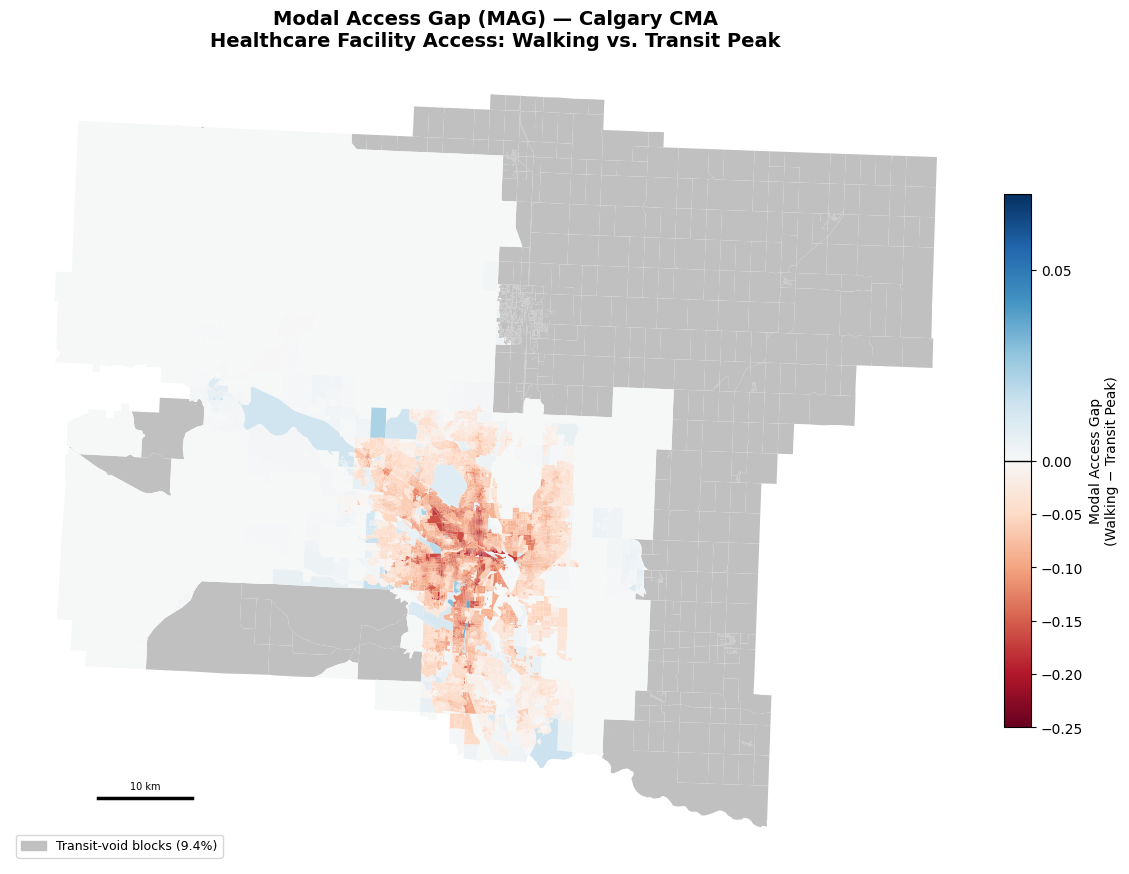

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig1_MAG_choropleth_DB.png


In [17]:
# Figure 1: MAG map (DB level: full granularity) 
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot transit-void blocks first in neutral colour
db_void = db_gdf[db_gdf['transit_void'] == True]
db_valid = db_gdf[db_gdf['transit_void'] == False]

db_void.plot(ax=ax, color='#c0c0c0', linewidth=0, label='Transit-void (no coverage)')

# Plot valid MAG blocks with RdBu diverging colormap centered at 0
vmin, vmax = -0.25, 0.07
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

sm = db_valid.plot(
    column='MAG', ax=ax,
    cmap='RdBu', norm=norm,
    linewidth=0, antialiased=True
)

# Colorbar
cbar = plt.colorbar(
    cm.ScalarMappable(norm=norm, cmap='RdBu'),
    ax=ax, shrink=0.55, pad=0.02
)
cbar.set_label('Modal Access Gap\n(Walking − Transit Peak)', fontsize=10)
cbar.ax.axhline(y=0, color='black', linewidth=1)

# Legend patch for void zones
void_patch = mpatches.Patch(color='#c0c0c0', label='Transit-void blocks (9.4%)')
ax.legend(handles=[void_patch], loc='lower left', fontsize=9, framealpha=0.8)

add_scalebar(ax, db_gdf)
clean_ax(ax, 'Modal Access Gap (MAG) — Calgary CMA\nHealthcare Facility Access: Walking vs. Transit Peak', fontsize=14)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig1_MAG_choropleth_DB.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

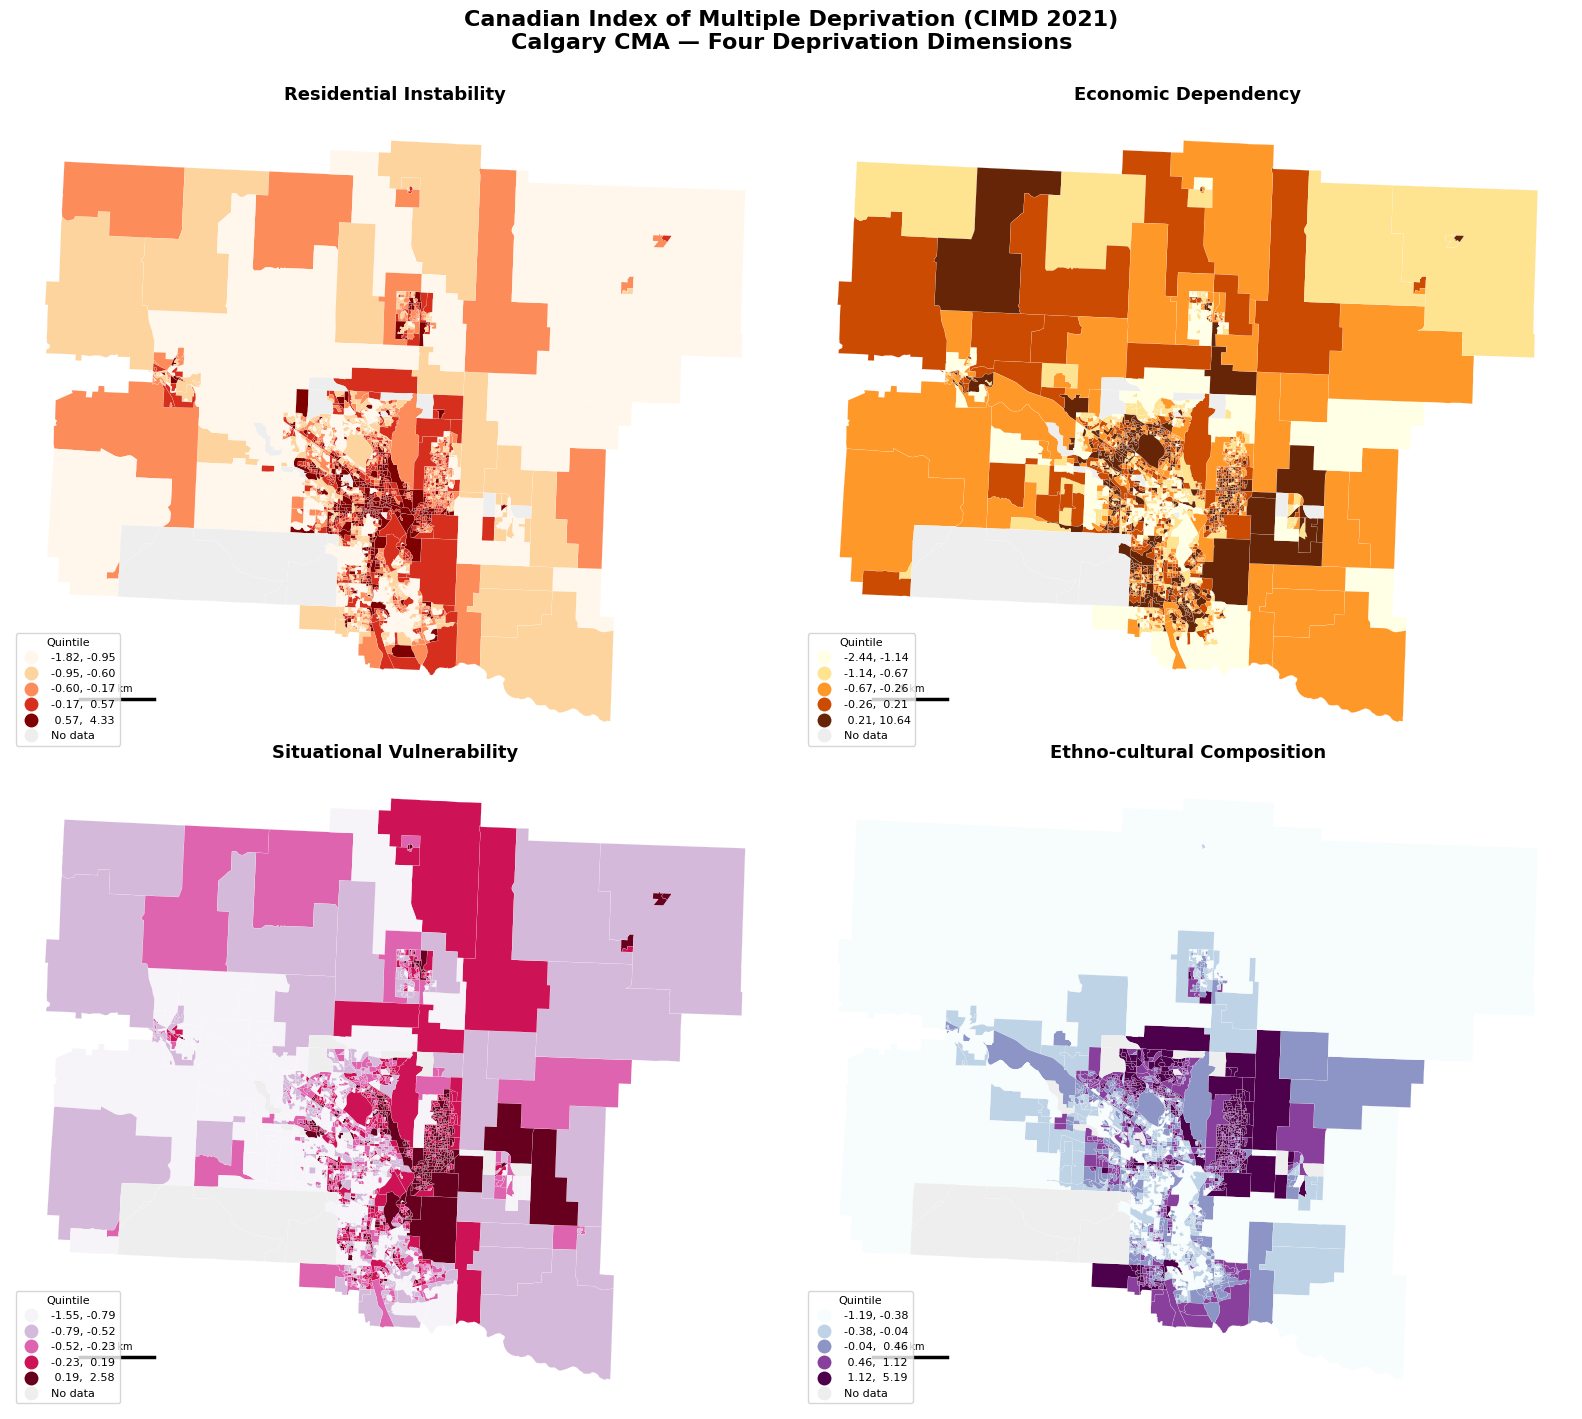

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig2_CIMD_4panel.png


In [18]:
# Figure 2: CIMD 4-panel map (DA level) 
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

cmaps = ['OrRd', 'YlOrBr', 'PuRd', 'BuPu']
titles = [
    'Residential Instability',
    'Economic Dependency',
    'Situational Vulnerability',
    'Ethno-cultural Composition'
]

for i, (col, title, cmap) in enumerate(zip(CIMD_SCORE_COLS, titles, cmaps)):
    da_gdf.plot(
        column=col, ax=axes[i],
        cmap=cmap,
        scheme='quantiles', k=5,
        legend=True,
        legend_kwds={
            'title': 'Quintile',
            'loc': 'lower left',
            'fontsize': 8,
            'title_fontsize': 8
        },
        missing_kwds={'color': '#eeeeee', 'label': 'No data'},
        linewidth=0.1, edgecolor='white'
    )
    clean_ax(axes[i], title, fontsize=13)
    add_scalebar(axes[i], da_gdf)

fig.suptitle(
    'Canadian Index of Multiple Deprivation (CIMD 2021)\nCalgary CMA — Four Deprivation Dimensions',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig2_CIMD_4panel.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

## 3. Bivariate Map: MAG & Economic Deprivation

A bivariate choropleth crosses two variables into a 3×3 colour matrix.
Use MAG (tertiles) × Economic Dependency (tertiles).
IMP: **high deprivation + large negative MAG** = access desert.

In [19]:

# 3x3 matrix: rows = MAG tertile (1=least gap, 3=most gap)
# cols = Economic Dependency tertile (1=least deprived, 3=most deprived)

# Stevens bivariate palette (blue x red = purple)
BIVAR_COLORS = [
    # econ dep:  low        mid        high
    '#e8e8e8', '#ace4e4', '#5ac8c8',  # MAG low (small gap)
    '#dfb0d6', '#a5add3', '#5698b9',  # MAG mid
    '#be64ac', '#8c62aa', '#3b4994',  # MAG high (large gap)
]

def assign_bivar(df, col_x, col_y):
    """Assign bivariate class (0-8) based on tertiles of two columns."""
    df = df.copy()
    # MAG is negative: flip so high class = worst gap
    df['_mag_neg'] = -df[col_x]   # negate so larger = worse
    df['_x_t'] = pd.qcut(df['_mag_neg'], q=3, labels=[0,1,2]).astype(int)
    df['_y_t'] = pd.qcut(df[col_y],      q=3, labels=[0,1,2]).astype(int)
    df['bivar_class'] = df['_x_t'] * 3 + df['_y_t']
    df['bivar_color'] = df['bivar_class'].map(lambda c: BIVAR_COLORS[c])
    return df

da_bivar = assign_bivar(
    da_clean,
    col_x='MAG_mean',
    col_y='Economic dependency Scores'
)

print('Bivariate class distribution:')
print(da_bivar['bivar_class'].value_counts().sort_index())

Bivariate class distribution:
bivar_class
0    236
1    190
2    167
3    129
4    209
5    254
6    229
7    194
8    170
Name: count, dtype: int64


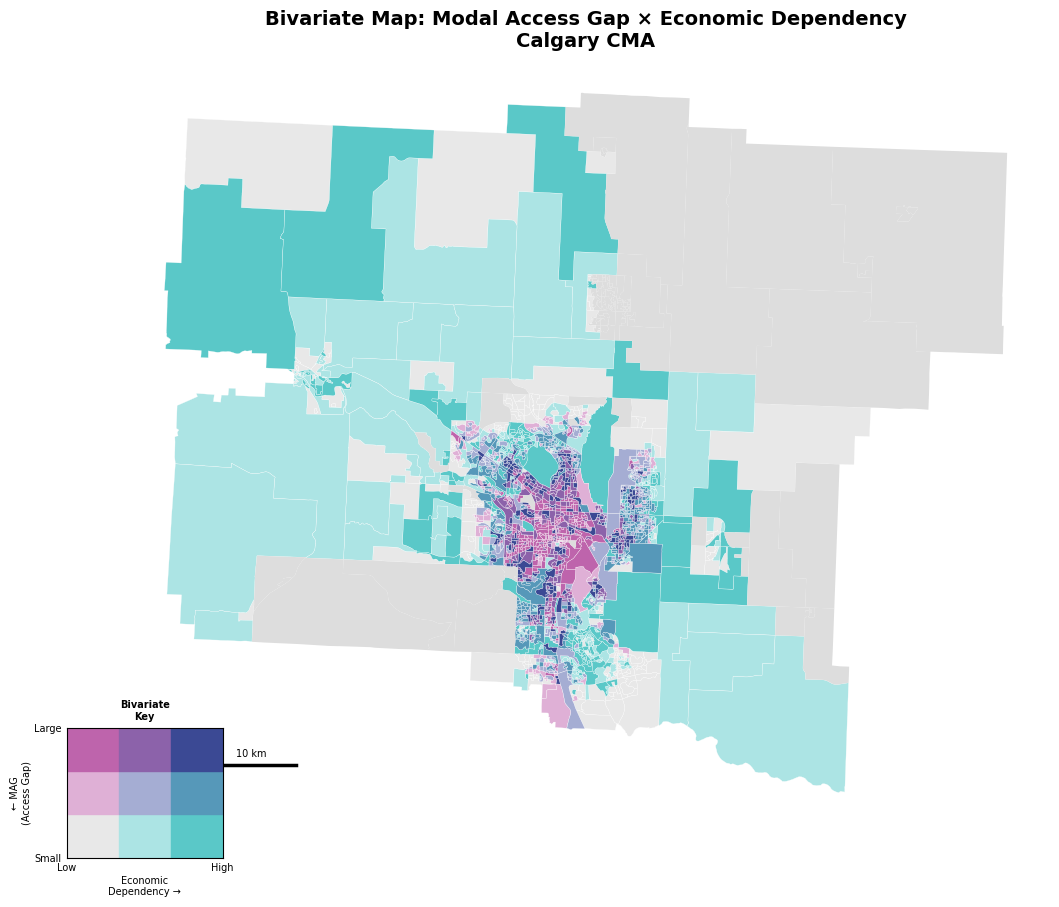

Saved: Fig3_bivariate_MAG_EconDep.png


In [20]:
# Plot bivariate map 
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot each bivariate class separately
for cls in range(9):
    subset = da_bivar[da_bivar['bivar_class'] == cls]
    if len(subset) > 0:
        subset.plot(ax=ax, color=BIVAR_COLORS[cls], linewidth=0.2,
                   edgecolor='white')

# Plot transit-void DAs in grey
da_void = da_gdf[~da_gdf['DAUID'].isin(da_bivar['DAUID'])]
if len(da_void) > 0:
    da_void.plot(ax=ax, color='#dddddd', linewidth=0.1)

clean_ax(ax, 'Bivariate Map: Modal Access Gap × Economic Dependency\nCalgary CMA', fontsize=14)
add_scalebar(ax, da_gdf)

# Inset legend (3x3 colour matrix)
leg_ax = fig.add_axes([0.08, 0.08, 0.13, 0.13])  # [left, bottom, width, height]
leg_matrix = np.array(BIVAR_COLORS).reshape(3, 3)
for r in range(3):
    for c in range(3):
        leg_ax.add_patch(plt.Rectangle(
            (c, r), 1, 1,
            color=leg_matrix[r, c]
        ))
leg_ax.set_xlim(0, 3)
leg_ax.set_ylim(0, 3)
leg_ax.set_xticks([0, 1.5, 3])
leg_ax.set_yticks([0, 1.5, 3])
leg_ax.set_xticklabels(['Low', '', 'High'], fontsize=7)
leg_ax.set_yticklabels(['Small', '', 'Large'], fontsize=7)
leg_ax.set_xlabel('Economic\nDependency →', fontsize=7, labelpad=2)
leg_ax.set_ylabel('← MAG\n(Access Gap)', fontsize=7, labelpad=2)
leg_ax.set_title('Bivariate\nKey', fontsize=7, fontweight='bold')
leg_ax.tick_params(length=0)

plt.savefig(os.path.join(OUTPUTS_DIR, 'Fig3_bivariate_MAG_EconDep.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: Fig3_bivariate_MAG_EconDep.png')

## 4. Getis-Ord Gi* Hotspot Analysis

Gi* identifies statistically significant spatial clusters of high or low MAG values.
- **Hot spots (z > 1.96):** Clusters of large negative MAG = access desert zones
- **Cold spots (z < -1.96):** Clusters of small MAG = transit serves walkers well here

In [21]:
# Build spatial weights matrix
# Queen contiguity: DA is neighbour if it shares any boundary point
# At DA level for hotspot

#da_clean (has complete MAG + CIMD)
da_clean = da_clean.reset_index(drop=True)

w = Queen.from_dataframe(da_clean, silence_warnings=True)
w.transform = 'r'   # row-standardise weights

print(f'Spatial weights built')
print(f'  Islands (no neighbours): {w.islands}')
print(f'  Mean neighbours        : {w.mean_neighbors:.2f}')

Spatial weights built
  Islands (no neighbours): []
  Mean neighbours        : 6.19


In [22]:
# Run Getis-Ord Gi*
# We negate MAG so that "hot spots" = areas of WORST access gap
mag_neg = -da_clean['MAG_mean'].values   # negate: higher = worse gap

gi = G_Local(mag_neg, w, transform='r', permutations=999, seed=42)

da_clean = da_clean.copy()
da_clean['Gi_z']   = gi.Zs
da_clean['Gi_p']   = gi.p_sim

# Classify into significance categories
def classify_hotspot(row):
    z, p = row['Gi_z'], row['Gi_p']
    if p <= 0.01 and z > 0:  return 'Hot spot 99%'
    if p <= 0.05 and z > 0:  return 'Hot spot 95%'
    if p <= 0.10 and z > 0:  return 'Hot spot 90%'
    if p <= 0.01 and z < 0:  return 'Cold spot 99%'
    if p <= 0.05 and z < 0:  return 'Cold spot 95%'
    if p <= 0.10 and z < 0:  return 'Cold spot 90%'
    return 'Not significant'

da_clean['hotspot_class'] = da_clean.apply(classify_hotspot, axis=1)

print('Gi* hotspot classification:')
print(da_clean['hotspot_class'].value_counts())

Gi* hotspot classification:
hotspot_class
Not significant    835
Cold spot 99%      268
Hot spot 99%       265
Cold spot 95%      144
Hot spot 95%       114
Cold spot 90%       78
Hot spot 90%        74
Name: count, dtype: int64


In [23]:
# Also run Global Moran's I for MAG
moran = Moran(mag_neg, w, permutations=999)
print(f"Global Moran's I for MAG : {moran.I:.4f}")
print(f"  p-value (permutation)  : {moran.p_sim:.4f}")
print(f"  z-score                : {moran.z_norm:.4f}")
print()
if moran.p_sim < 0.05:
    print('Statistically significant spatial autocorrelation in MAG')
    print('Access deserts are spatially clustered, not randomly distributed')
else:
    print('No significant spatial autocorrelation detected')

Global Moran's I for MAG : 0.8228
  p-value (permutation)  : 0.0010
  z-score                : 57.8004

Statistically significant spatial autocorrelation in MAG
Access deserts are spatially clustered, not randomly distributed


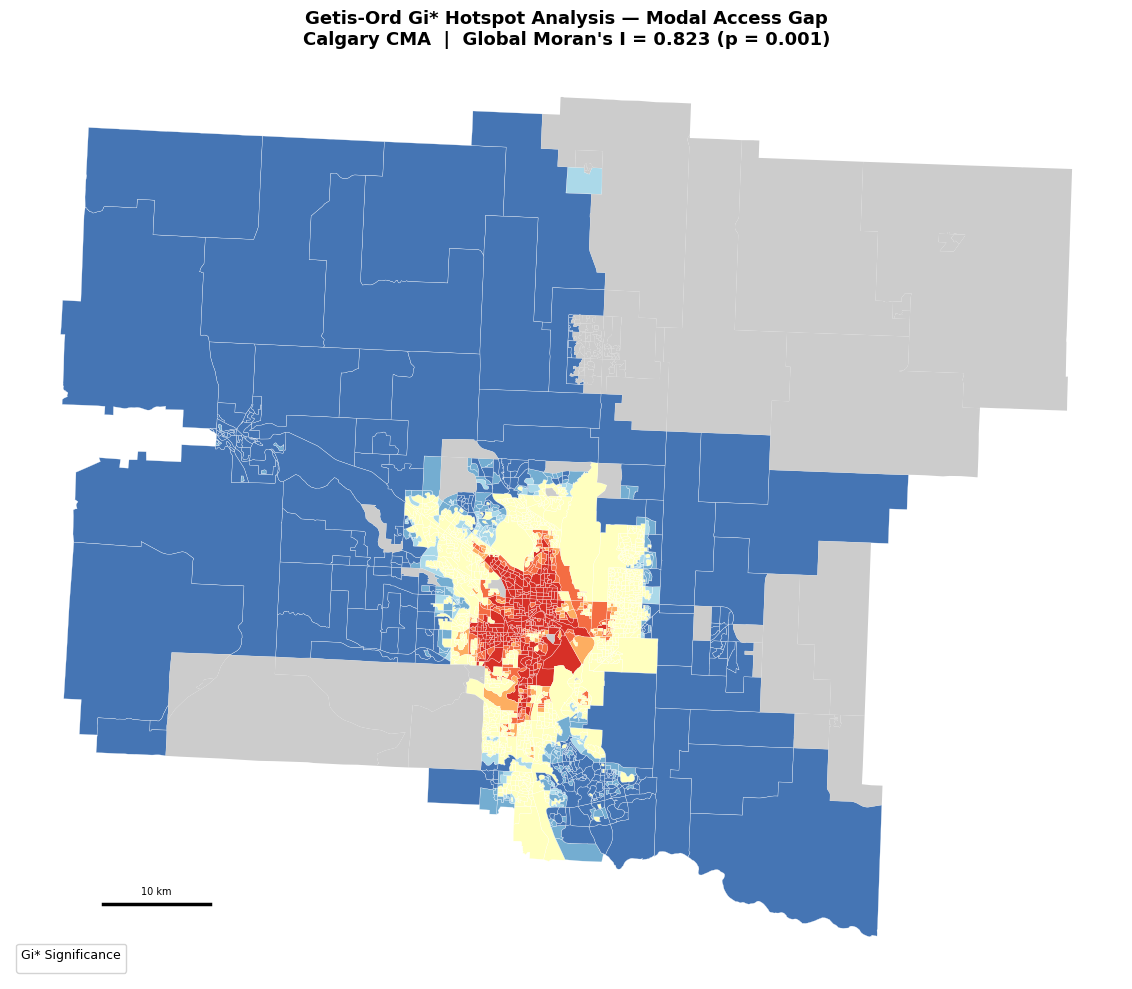

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig4_Gi_hotspot_MAG.png


In [24]:
# Plot Gi* hotspot map
HOTSPOT_COLORS = {
    'Hot spot 99%'   : '#d73027',
    'Hot spot 95%'   : '#f46d43',
    'Hot spot 90%'   : '#fdae61',
    'Not significant': '#ffffbf',
    'Cold spot 90%'  : '#abd9e9',
    'Cold spot 95%'  : '#74add1',
    'Cold spot 99%'  : '#4575b4',
}

fig, ax = plt.subplots(figsize=(12, 10))

for cls, color in HOTSPOT_COLORS.items():
    subset = da_clean[da_clean['hotspot_class'] == cls]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=0.2,
                   edgecolor='white', label=cls)

# DAs without complete data
da_missing = da_gdf[~da_gdf['DAUID'].isin(da_clean['DAUID'])]
if len(da_missing) > 0:
    da_missing.plot(ax=ax, color='#cccccc', linewidth=0.1, label='Insufficient data')

ax.legend(loc='lower left', fontsize=9, framealpha=0.85,
          title='Gi* Significance', title_fontsize=9)
add_scalebar(ax, da_clean)

clean_ax(ax,
    f"Getis-Ord Gi* Hotspot Analysis — Modal Access Gap\n"
    f"Calgary CMA  |  Global Moran's I = {moran.I:.3f} (p = {moran.p_sim:.3f})",
    fontsize=13
)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig4_Gi_hotspot_MAG.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

## 5. Correlation Analysis: Deprivation Dimensions vs MAG

In [25]:
from scipy import stats

# Pearson + Spearman correlations: each CIMD dim vs MAG_mean
results = []
for col in CIMD_SCORE_COLS:
    sub = da_clean[['MAG_mean', col]].dropna()
    r_p, p_p = stats.pearsonr(sub['MAG_mean'], sub[col])
    r_s, p_s = stats.spearmanr(sub['MAG_mean'], sub[col])
    results.append({
        'Dimension'        : col.replace(' Scores',''),
        'Pearson r'        : round(r_p, 4),
        'Pearson p'        : round(p_p, 4),
        'Spearman rho'     : round(r_s, 4),
        'Spearman p'       : round(p_s, 4),
        'Significant'      : 'yes' if p_s < 0.05 else 'no'
    })

corr_df = pd.DataFrame(results)
print('Correlation of CIMD dimensions with MAG:')
print(corr_df.to_string(index=False))

Correlation of CIMD dimensions with MAG:
                 Dimension  Pearson r  Pearson p  Spearman rho  Spearman p Significant
   Residential instability    -0.5105     0.0000       -0.4869      0.0000         yes
       Economic dependency     0.0398     0.0937        0.0034      0.8858          no
 Situational vulnerability    -0.1161     0.0000       -0.1598      0.0000         yes
Ethno-cultural composition     0.0196     0.4090        0.0095      0.6887          no


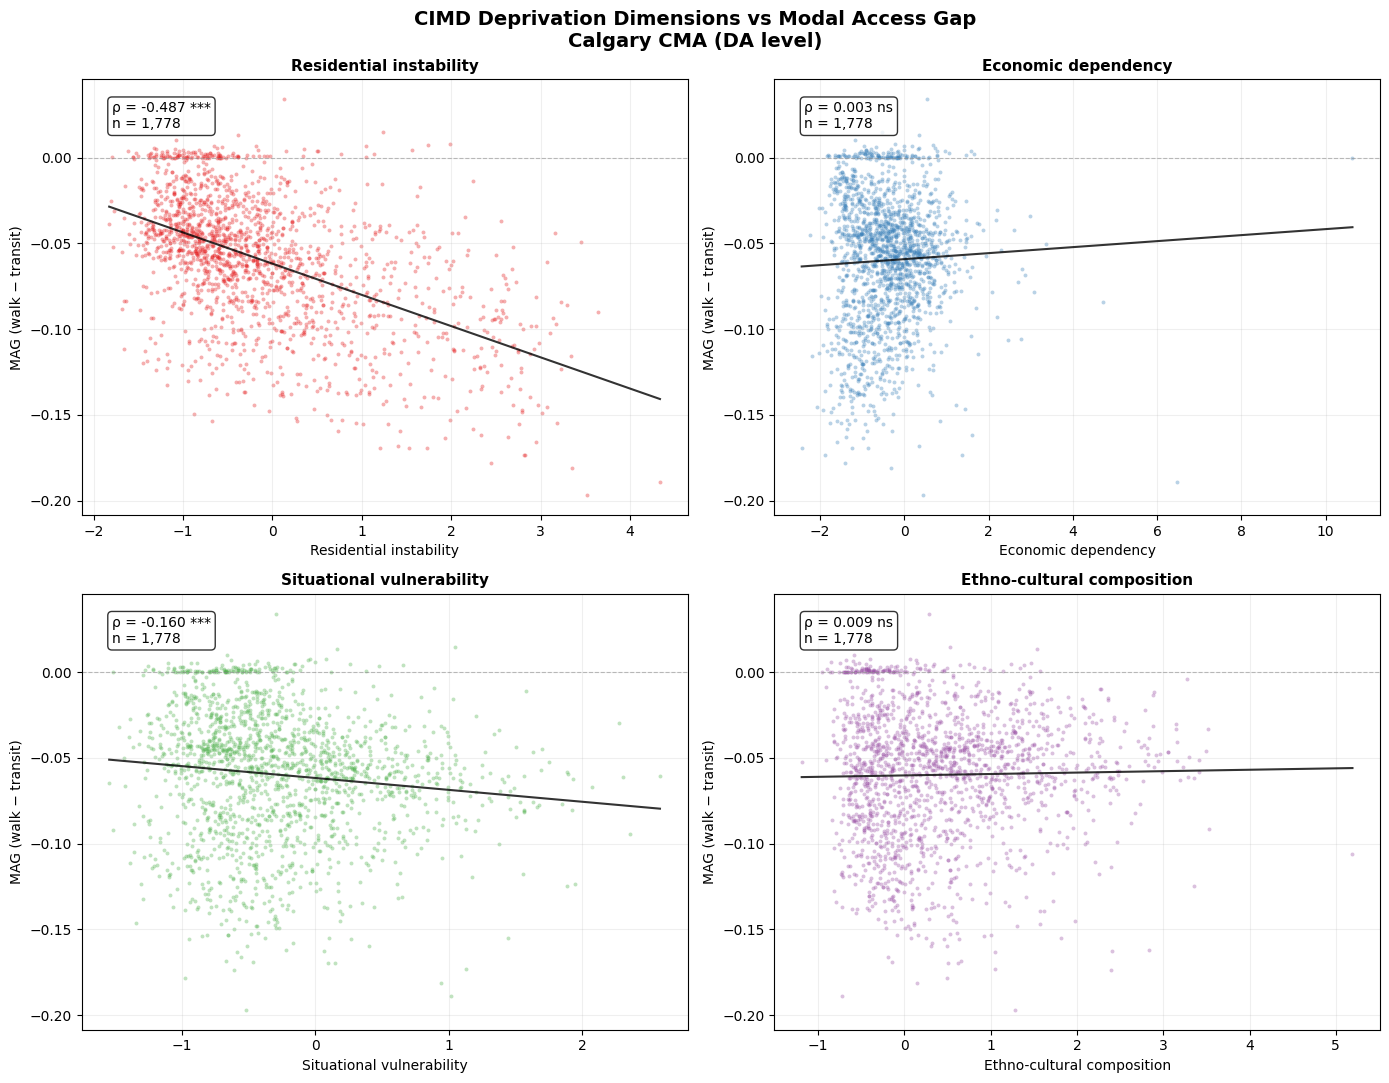

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig5_correlation_scatter.png


In [26]:
# Figure 5: Correlation heatmap + scatter panels
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

colors_scatter = ['#e41a1c','#377eb8','#4daf4a','#984ea3']

for i, (col, color) in enumerate(zip(CIMD_SCORE_COLS, colors_scatter)):
    sub = da_clean[['MAG_mean', col]].dropna()
    ax = axes[i]

    # Scatter
    ax.scatter(sub[col], sub['MAG_mean'],
               alpha=0.35, s=8, color=color, linewidths=0)

    # OLS trend line
    m, b, r, p, se = stats.linregress(sub[col], sub['MAG_mean'])
    x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=1.5, alpha=0.8)

    # Annotations
    r_s = corr_df[corr_df['Dimension']==col.replace(' Scores','')]['Spearman rho'].values[0]
    p_s = corr_df[corr_df['Dimension']==col.replace(' Scores','')]['Spearman p'].values[0]
    sig = '***' if p_s<0.001 else ('**' if p_s<0.01 else ('*' if p_s<0.05 else 'ns'))
    ax.text(0.05, 0.95,
            f'ρ = {r_s:.3f} {sig}\nn = {len(sub):,}',
            transform=ax.transAxes, fontsize=10,
            va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel(col.replace(' Scores',''), fontsize=10)
    ax.set_ylabel('MAG (walk − transit)', fontsize=10)
    ax.set_title(col.replace(' Scores',''), fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'CIMD Deprivation Dimensions vs Modal Access Gap\nCalgary CMA (DA level)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig5_correlation_scatter.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

## 6. Transit-Void Zone 

transit-void blocks vs. non-void blocks using CIMD dimensions.

In [28]:
# Join transit-void flag to DA level
# A DA is 'void-dominant' if >50% of its DBs are transit-void
db_void_rate = db_gdf.copy()
db_void_rate['DAUID'] = db_void_rate['DBUID'].astype(str).str[:8]

void_by_da = db_void_rate.groupby('DAUID').agg(
    total_blocks = ('DBUID', 'count'),
    void_blocks  = ('transit_void', 'sum')
).reset_index()
void_by_da['void_rate'] = void_by_da['void_blocks'] / void_by_da['total_blocks']
void_by_da['void_dominant'] = void_by_da['void_rate'] > 0.5

# Merge into da_clean
da_void_analysis = da_clean.merge(void_by_da[['DAUID','void_rate','void_dominant']],
                                   on='DAUID', how='left')

print('Void-dominant DAs (>50% blocks have no transit):')
print(f'  Count : {da_void_analysis["void_dominant"].sum():,}')
print(f'  Share : {100*da_void_analysis["void_dominant"].mean():.1f}%')

# Compare deprivation scores: void-dominant vs transit-served
print('\nMean deprivation scores: void-dominant vs transit-served DAs:')
comparison = da_void_analysis.groupby('void_dominant')[CIMD_SCORE_COLS].mean().round(4)
comparison.index = ['Transit-served', 'Void-dominant']
print(comparison.to_string())

Void-dominant DAs (>50% blocks have no transit):
  Count : 11
  Share : 0.6%

Mean deprivation scores: void-dominant vs transit-served DAs:
                Residential instability Scores  Economic dependency Scores  Situational vulnerability Scores  Ethno-cultural composition Scores
Transit-served                         -0.1046                     -0.3840                           -0.2675                             0.4347
Void-dominant                          -0.5642                     -0.5795                           -0.5251                            -0.1518


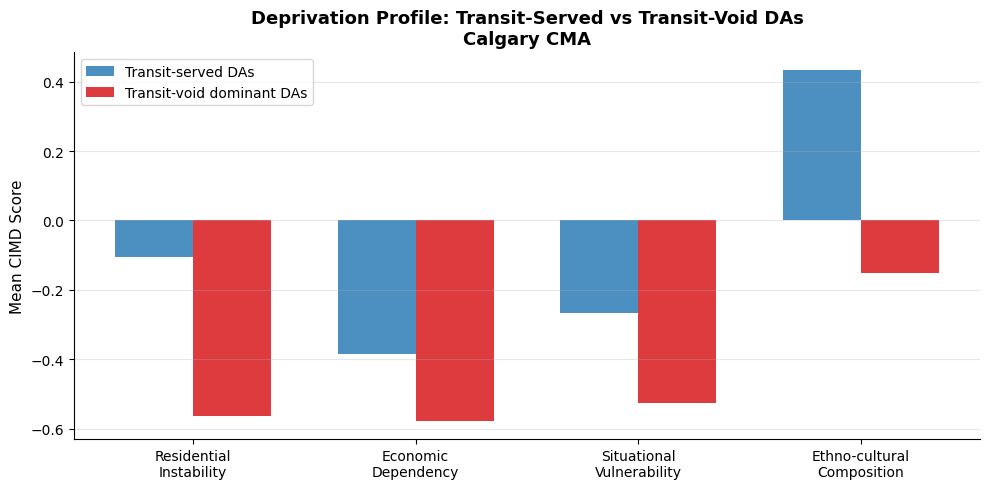

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig6_void_zone_profile.png


In [29]:
# Figure 6: Void zone profile bar chart
fig, ax = plt.subplots(figsize=(10, 5))

short_labels = ['Residential\nInstability', 'Economic\nDependency',
                'Situational\nVulnerability', 'Ethno-cultural\nComposition']
x = np.arange(len(short_labels))
width = 0.35

served_means = da_void_analysis[da_void_analysis['void_dominant']==False][CIMD_SCORE_COLS].mean()
void_means   = da_void_analysis[da_void_analysis['void_dominant']==True][CIMD_SCORE_COLS].mean()

bars1 = ax.bar(x - width/2, served_means.values, width,
               label='Transit-served DAs', color='#2c7bb6', alpha=0.85)
bars2 = ax.bar(x + width/2, void_means.values, width,
               label='Transit-void dominant DAs', color='#d7191c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylabel('Mean CIMD Score', fontsize=11)
ax.set_title('Deprivation Profile: Transit-Served vs Transit-Void DAs\nCalgary CMA',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig6_void_zone_profile.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

## 7. Summary

In [31]:
print('SUMMARY/ FINDINGS')

print(f"""
STUDY AREA
  Calgary CMA
  Total DBs analysed         : {len(db_gdf):,}
  Total DAs analysed         : {len(da_gdf):,}
  DAs with complete data     : {len(da_clean):,}

MODAL ACCESS GAP (MAG)
  Mean MAG                   : {db_gdf['MAG'].mean():.4f}
  Std Dev                    : {db_gdf['MAG'].std():.4f}
  Min / Max                  : {db_gdf['MAG'].min():.4f} / {db_gdf['MAG'].max():.4f}
  DBs with negative MAG (%)  : {100*(db_gdf['MAG']<0).sum()/db_gdf['MAG'].notna().sum():.1f}%
  Transit-void blocks        : {db_gdf['transit_void'].sum():,} ({100*db_gdf['transit_void'].mean():.1f}%)

SPATIAL AUTOCORRELATION
  Global Moran's I           : {moran.I:.4f}
  p-value                    : {moran.p_sim:.4f}

HOTSPOT ANALYSIS
""")
print(da_clean['hotspot_class'].value_counts().to_string())

print("\nCORRELATION WITH CIMD DIMENSIONS")
print(corr_df[['Dimension','Spearman rho','Spearman p','Significant']].to_string(index=False))

# Save summary to text file
summary_path = os.path.join(OUTPUTS_DIR, 'NB2_summary_findings.txt')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(corr_df.to_string())
print(f'\nSaved: {summary_path}')


SUMMARY/ FINDINGS

STUDY AREA
  Calgary CMA
  Total DBs analysed         : 11,251
  Total DAs analysed         : 1,898
  DAs with complete data     : 1,778

MODAL ACCESS GAP (MAG)
  Mean MAG                   : -0.0589
  Std Dev                    : 0.0454
  Min / Max                  : -0.2368 / 0.0650
  DBs with negative MAG (%)  : 86.6%
  Transit-void blocks        : 1,056 (9.4%)

SPATIAL AUTOCORRELATION
  Global Moran's I           : 0.8228
  p-value                    : 0.0010

HOTSPOT ANALYSIS

hotspot_class
Not significant    835
Cold spot 99%      268
Hot spot 99%       265
Cold spot 95%      144
Hot spot 95%       114
Cold spot 90%       78
Hot spot 90%        74

CORRELATION WITH CIMD DIMENSIONS
                 Dimension  Spearman rho  Spearman p Significant
   Residential instability       -0.4869      0.0000         yes
       Economic dependency        0.0034      0.8858          no
 Situational vulnerability       -0.1598      0.0000         yes
Ethno-cultural compositio